In [29]:
import json
import hashlib

import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import math

import numpy as np

import pysrat.nhpp as srm
from pysrat.data import NHPPData, SMetricsData
from pysrat.nhpp.regression import fit_pr_nhpp

from sklearn.decomposition import PCA

In [34]:
def load_embedding_dataframe(jsonl_path: str) -> pd.DataFrame:
    """
    Load group_embeddings.jsonl and return DataFrame:
      index: folder
      columns: b1, b2, ..., bN
    """
    jsonl_path = Path(jsonl_path)

    folders = []
    vectors = []

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            folder = obj["folder"]
            emb = obj["embedding"]

            folders.append(folder)
            vectors.append(emb)

    if not vectors:
        raise ValueError("No embeddings found in file.")

    dim = len(vectors[0])
    columns = [f"b{i+1}" for i in range(dim)]

    df = pd.DataFrame(vectors, index=folders, columns=columns)
    df.index.name = "folder"

    return df

def folder_to_hash(folder: str) -> str:
    """
    Convert folder string to stable SHA1 hash.
    """
    return hashlib.sha1(folder.encode("utf-8")).hexdigest()


def load_nhpp_from_folder(folder: str, faultdata_dir: str = "faultdata"):
    """
    Given a folder name, load corresponding NHPPData object from:
        faultdata/<hash>.csv

    Returns:
        NHPPData.NHPPData object
    """
    hash_value = folder_to_hash(folder)
    csv_path = Path(faultdata_dir) / f"{hash_value}.csv"

    if not csv_path.exists():
        raise FileNotFoundError(f"Fault data not found: {csv_path}")

    try:
        data = pd.read_csv(csv_path)
        # extract week and counts columns
        tt = []
        nn = []
        for _, row in data.iterrows():
            tt.extend([1] * row["week"])
            nn.extend([row["counts"]] * row["week"])
        data = NHPPData.from_intervals(
            intervals=np.array(tt[302:]),
            counts=np.array(nn[302:])
        )
        # data = NHPPData.from_csv(
        #     str(csv_path),
        #     intervals="week",
        #     counts="counts"
        # )
    except Exception as e:
        raise ValueError(f"Error loading NHPP data from {csv_path}: {e}")

    return data

def load_all_data(df: pd.DataFrame, faultdata_dir: str = "faultdata") -> dict:
    """
    Load NHPPData for all folders in the DataFrame index.

    Returns:
        dict mapping folder name to NHPPData object
    """
    data_dict = {}
    for folder in df.index:
        try:
            data = load_nhpp_from_folder(folder, faultdata_dir)
        except (FileNotFoundError, ValueError):
            continue
        data_dict[folder] = data
    return data_dict

def plot_models_grid(models, ncols=5, nrows=5):
    keys = list(models.keys())
    per_page = ncols * nrows
    total = len(keys)
    pages = math.ceil(total / per_page)

    for p in range(pages):
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12))
        axes = axes.flatten()

        start = p * per_page
        end = min(start + per_page, total)

        for ax in axes:
            ax.clear()

        for i, k in enumerate(keys[start:end]):
            m = models[k]
            ax = axes[i]
            srm.plot_mvf(m.data_, m, ax=ax, title=k)

        for j in range(end - start, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

In [35]:
def data_truncation(data: NHPPData, t_end: int) -> NHPPData:
    """
    Truncate NHPPData to time t_end.
    """
    print(f"Truncating to t_end={t_end}")
    dat = {}
    for k, d in data.items():
        try:
            truncated = d.truncate(t_end=t_end)
        except Exception:
            continue
        if truncated.total_fault > 0:
            dat[k] = truncated
    return dat

def pred_err(models, faultdata0, faultdata1):
    err = sum([abs((m.mvf(faultdata1[k].total_time)-m.mvf(faultdata0[k].total_time)) - (sum(faultdata1[k].fault) - sum(faultdata0[k].fault))) for k,m in models.items()])
    return err

def test_for_lambd(lambd, faultdata0, faultdata1, smetdat, alpha=0.5):
    models = {k: srm.CanonicalPhaseTypeNHPP(20).fit(d) for k,d in faultdata0.items()}
    result = fit_pr_nhpp(models, smetdat, initialize=True, alpha=alpha, lambd=lambd)
    err = pred_err(models, faultdata0, faultdata1)
    return result, err

In [36]:
df = load_embedding_dataframe("group_embeddings.jsonl")
met = pd.read_csv('module_metrics.csv', index_col=0)
diff = met.index.symmetric_difference(df.index)
df = df.drop(diff, errors="ignore")
assert set(df.index) == set(met.index), "Mismatch in number of folders after alignment"

In [37]:
faultdata = load_all_data(df)
next(iter(faultdata.values())).total_time

# zero check
t_end = [604, 619, 634, 649, 664]
t_end = [t - 302 for t in t_end]
target_modules = set(faultdata.keys())
for t in t_end:
    truncated_data = data_truncation(faultdata, t_end=t)
    target_modules = target_modules & truncated_data.keys()
print('# of modules: ', len(target_modules))
df = df[df.index.isin(target_modules)]
tmp = {k: d for k,d in faultdata.items() if k in target_modules}
faultdata = [{k: d.truncate(t_end=t_end[i]) for k,d in tmp.items()} for i in range(len(t_end)-1)]
faultdata.append(tmp)

Truncating to t_end=302
Truncating to t_end=317
Truncating to t_end=332
Truncating to t_end=347
Truncating to t_end=362
# of modules:  64


In [38]:
# baseline
for i in range(len(t_end)-1):
    print(f"Fitting NHPP models for t_end={t_end[i]} with {len(faultdata[i])} modules...")
    models = {k: srm.CanonicalPhaseTypeNHPP(20).fit(d) for k,d in faultdata[i].items()}
    print("Prediction error (baseline, MAE): ", pred_err(models, faultdata[i], faultdata[i+1]))

Fitting NHPP models for t_end=302 with 64 modules...


/Users/okamu/Documents/pysrat-experiments/venv/lib/python3.9/site-packages/pysrat/nhpp/_em.py:231: UserWarning: Did not converge to MLE by max iteration.
  warnings.warn("Did not converge to MLE by max iteration.")


Prediction error (baseline, MAE):  1521.620656820612
Fitting NHPP models for t_end=317 with 64 modules...
Prediction error (baseline, MAE):  796.2850995434256
Fitting NHPP models for t_end=332 with 64 modules...
Prediction error (baseline, MAE):  406.48582517144405
Fitting NHPP models for t_end=347 with 64 modules...
Prediction error (baseline, MAE):  211.37646526453466


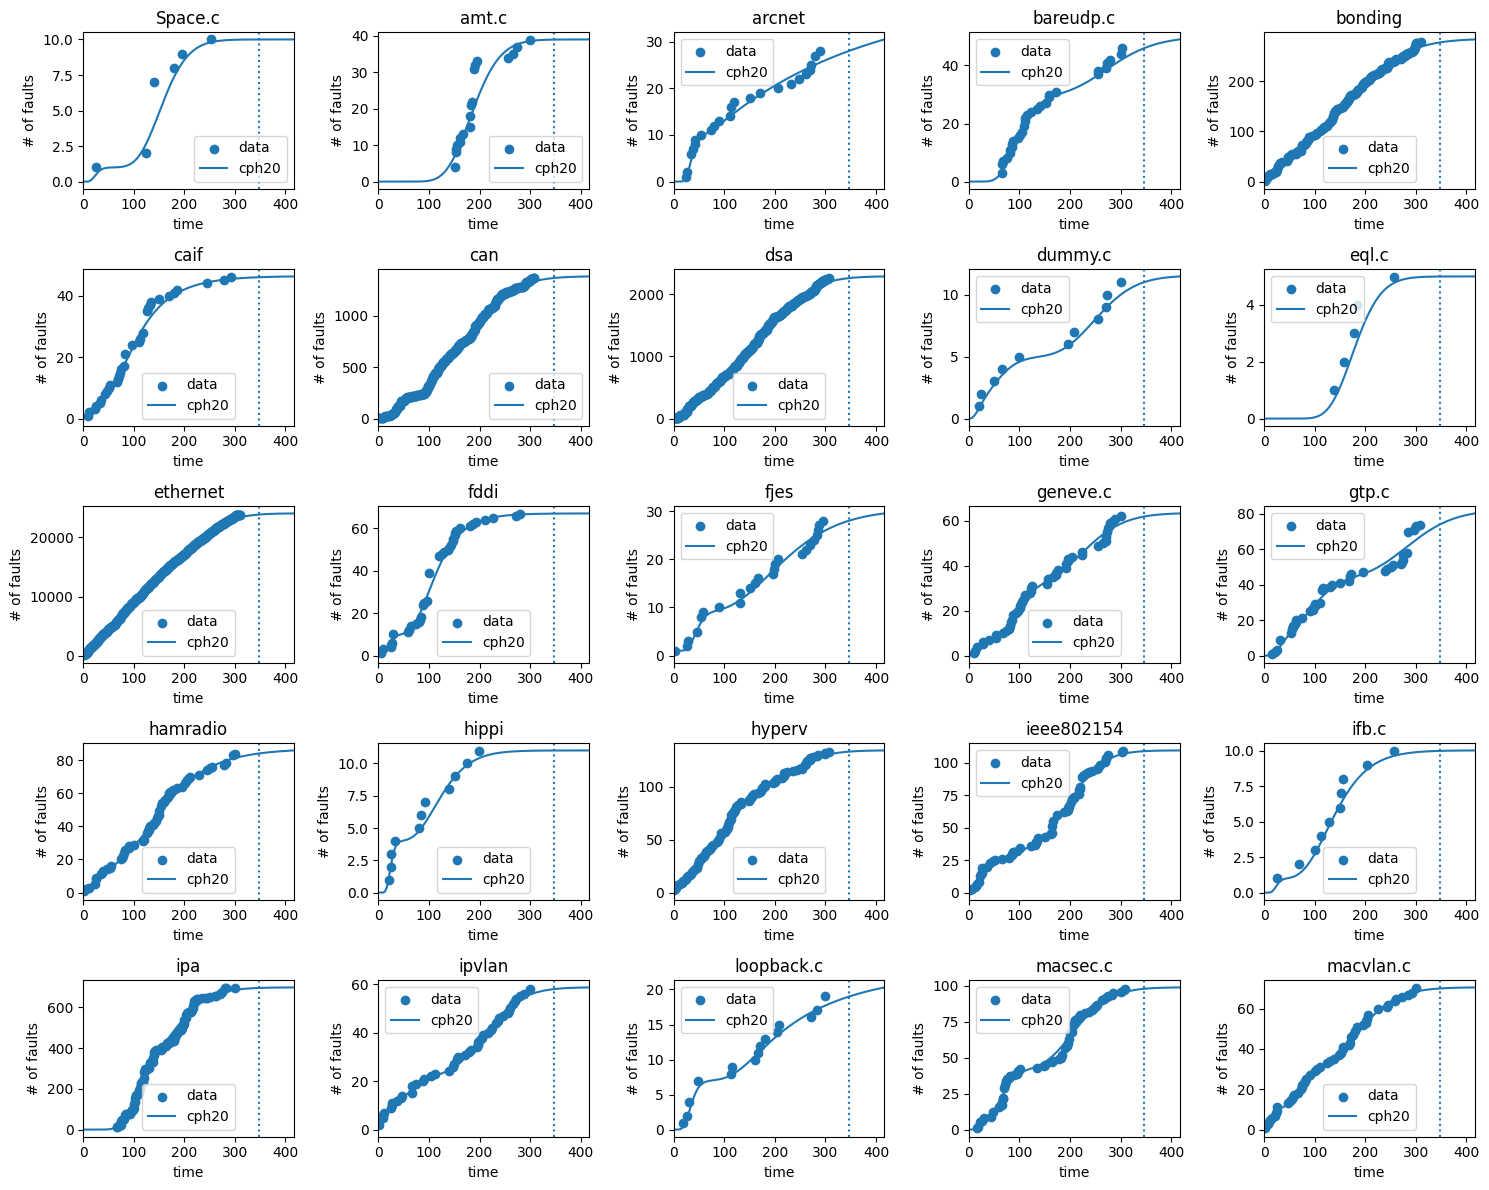

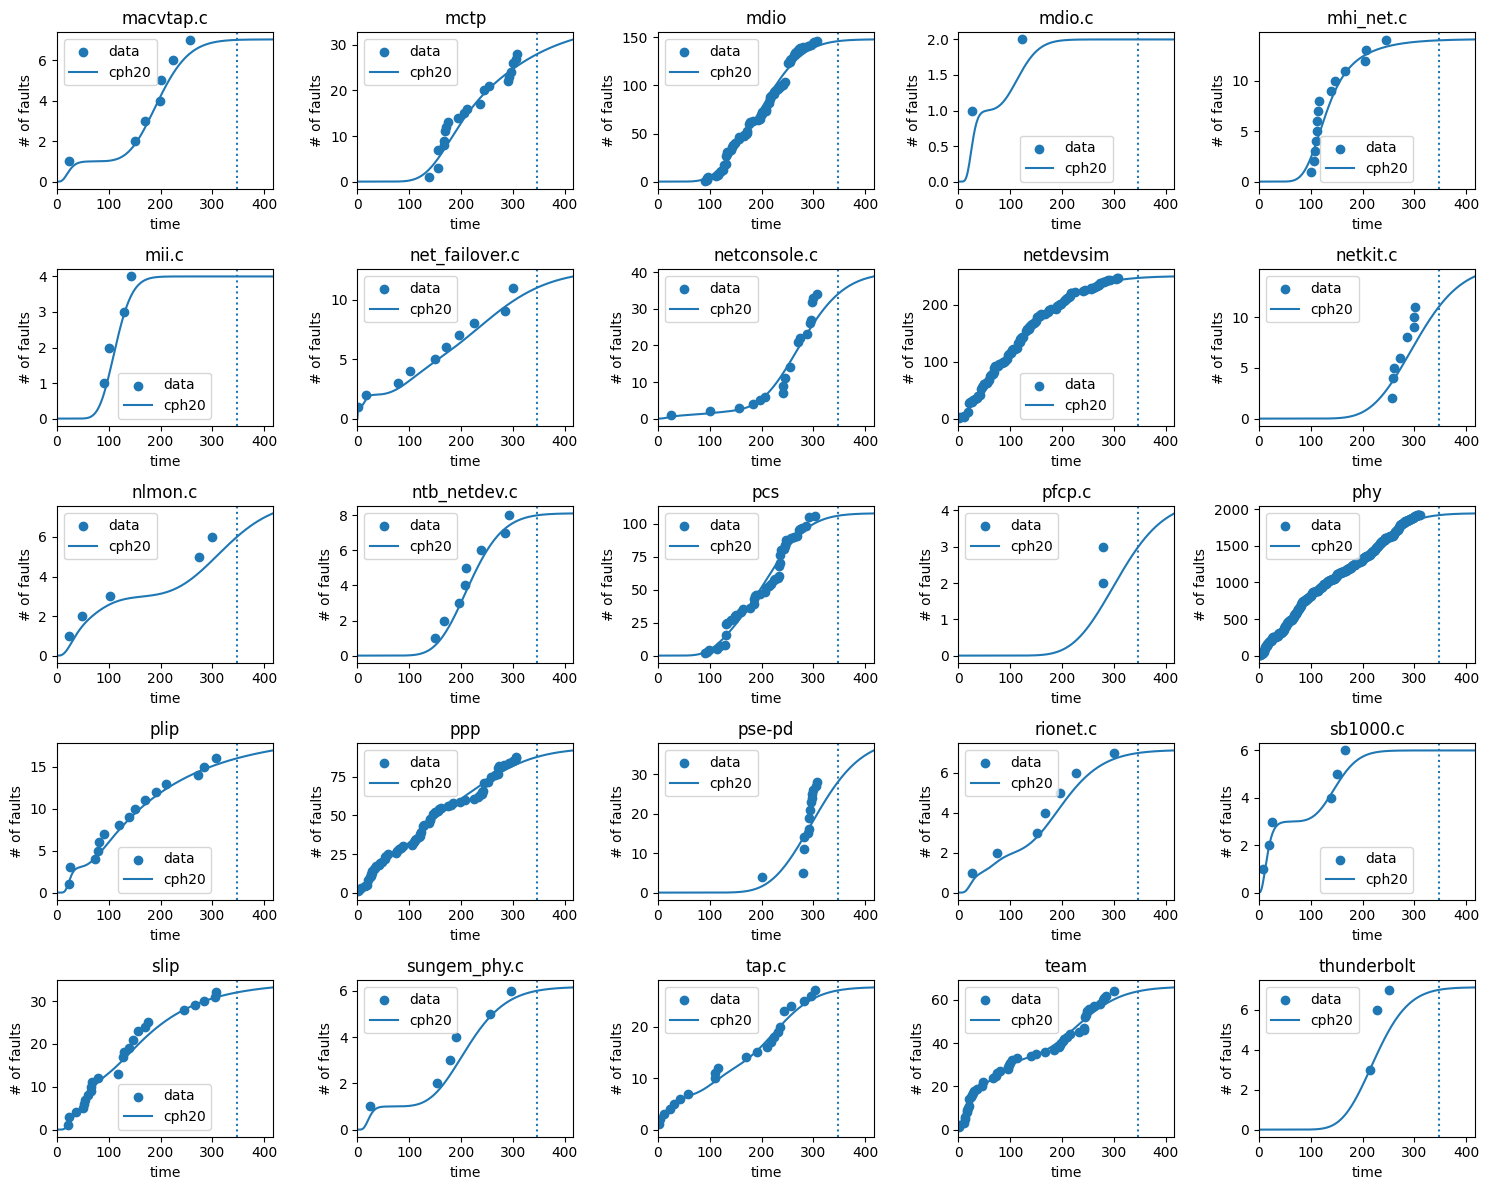

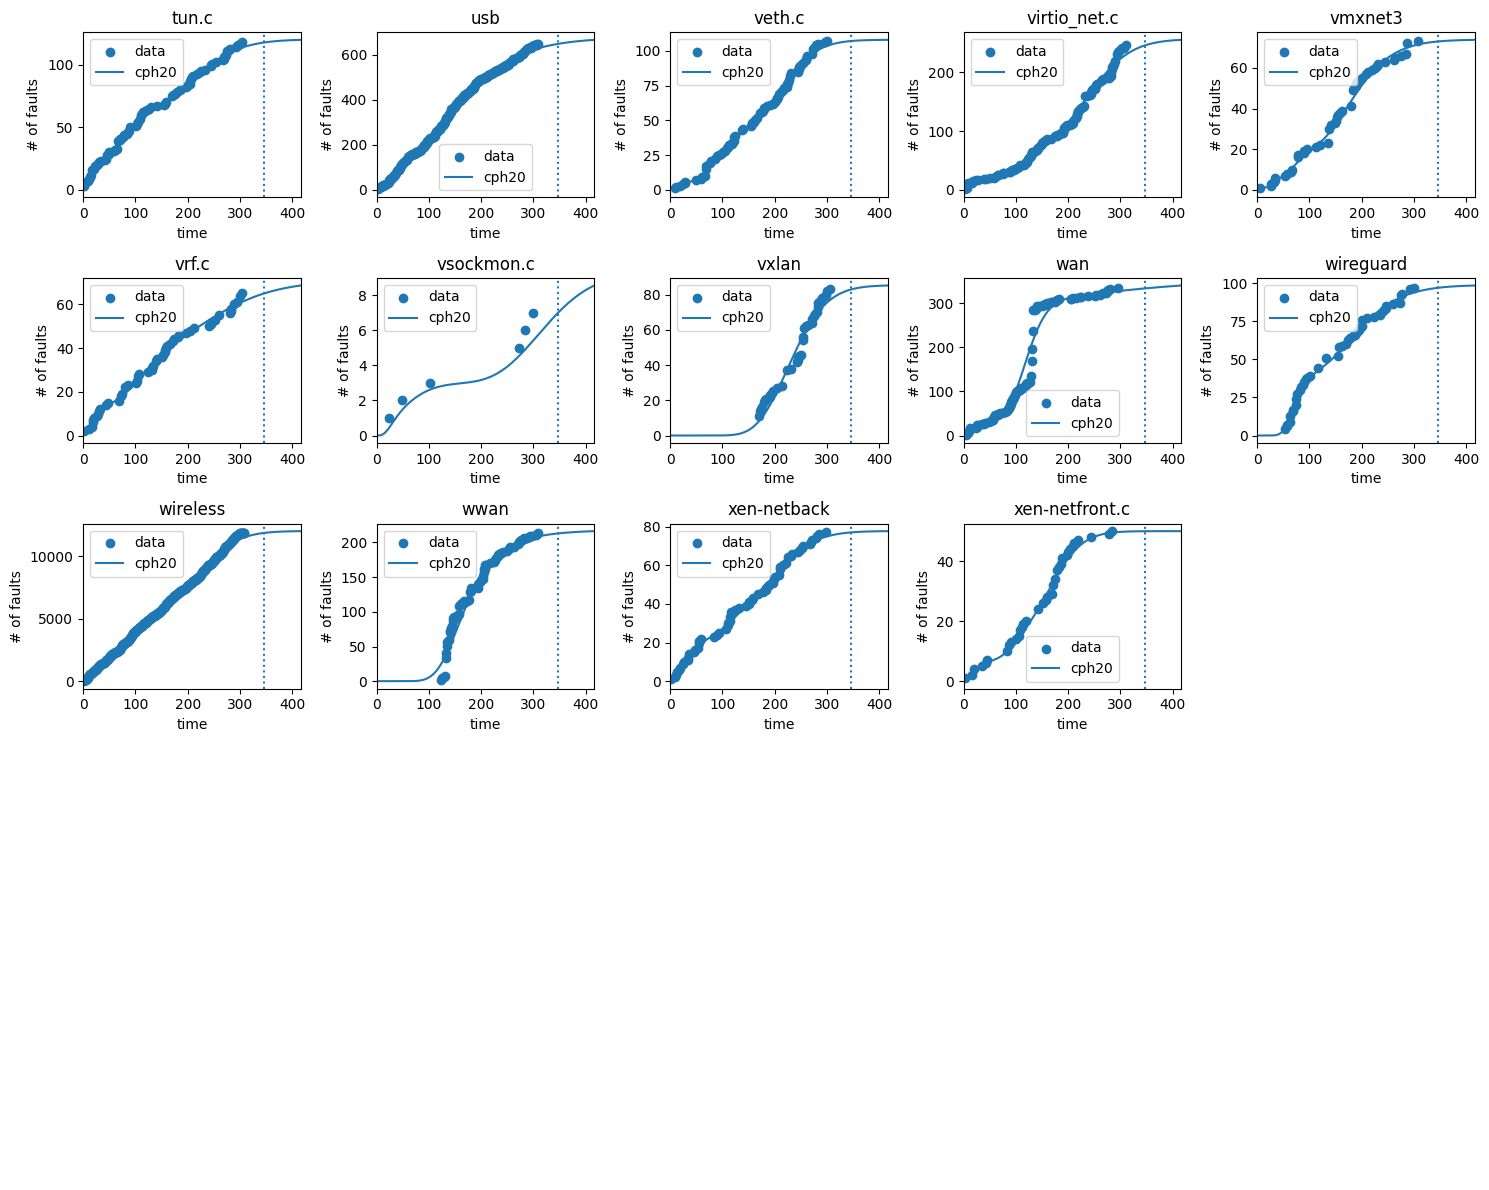

In [39]:
plot_models_grid(models, ncols=5, nrows=5)

In [60]:
pca = PCA(n_components=len(target_modules))
X_pca = pca.fit_transform(df.values)
df_pca = pd.DataFrame(
    X_pca,
    index=df.index,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
smetdat = SMetricsData.from_dataframe(df_pca, use_index_as_name=True)

In [ ]:
allresults = []
for i in range(len(faultdata)-1):
    cvresults = {}
    for lambd in [0.1, 0.3, 1.0, 3.0, 10.0, 30.0 100.0, 200.0, 250.0, 300.0, 350.0, 400.0, 500.0, 700.0, 100.0]:
        result, err = test_for_lambd(lambd, faultdata[i], faultdata[i+1], smetdat)
        cvresults[f'{lambd}'] = result
        print(f'lambda: {lambd}, prederr: {err}, faultdata{i}, faultdata{i+1}')
    allresults.append(cvresults)

/Users/okamu/Documents/experiments/.venv/lib/python3.9/site-packages/pysrat/nhpp/_em.py:231: UserWarning: Did not converge to MLE by max iteration.
  warnings.warn("Did not converge to MLE by max iteration.")
/Users/okamu/Documents/experiments/.venv/lib/python3.9/site-packages/pysrat/nhpp/regression/pr_nhpp.py:77: RuntimeWarning: divide by zero encountered in matmul
  eta = float(intercept) + (np.asarray(X, dtype=float) @ np.asarray(beta, dtype=float))
/Users/okamu/Documents/experiments/.venv/lib/python3.9/site-packages/pysrat/nhpp/regression/pr_nhpp.py:77: RuntimeWarning: overflow encountered in matmul
  eta = float(intercept) + (np.asarray(X, dtype=float) @ np.asarray(beta, dtype=float))
/Users/okamu/Documents/experiments/.venv/lib/python3.9/site-packages/pysrat/nhpp/regression/pr_nhpp.py:77: RuntimeWarning: invalid value encountered in matmul
  eta = float(intercept) + (np.asarray(X, dtype=float) @ np.asarray(beta, dtype=float))


305.58556758293344
302.9647908771219
301.0322307295069


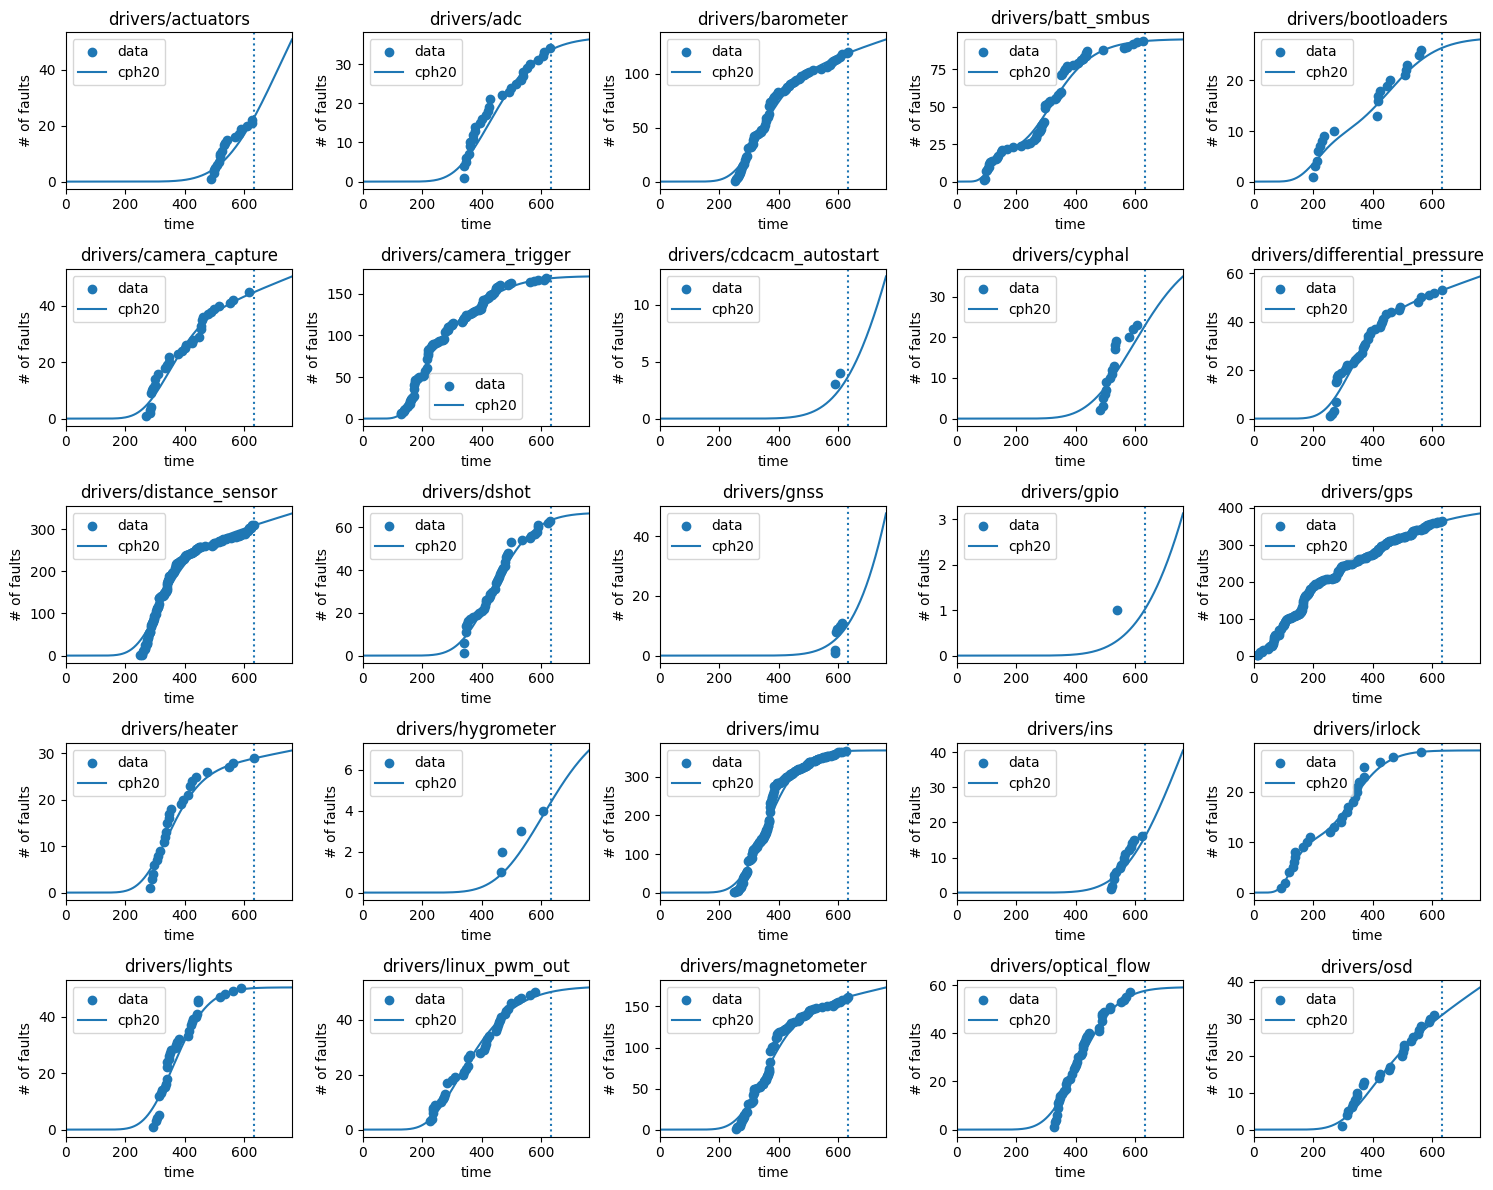

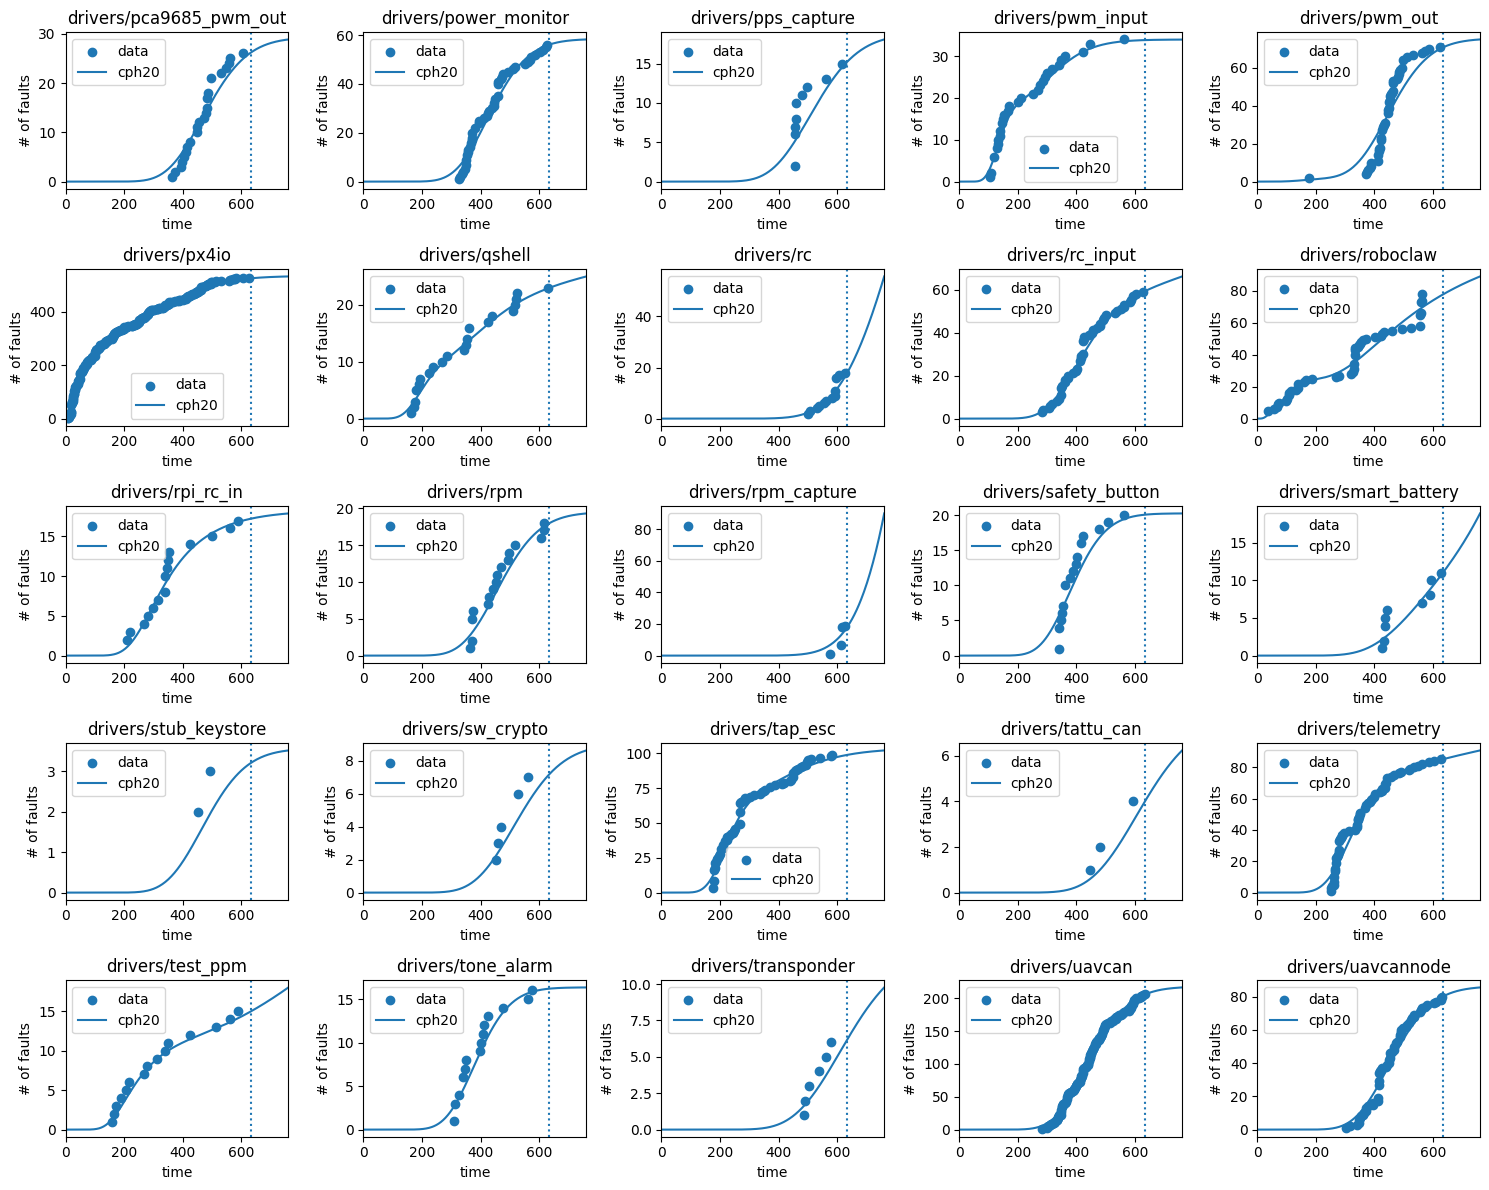

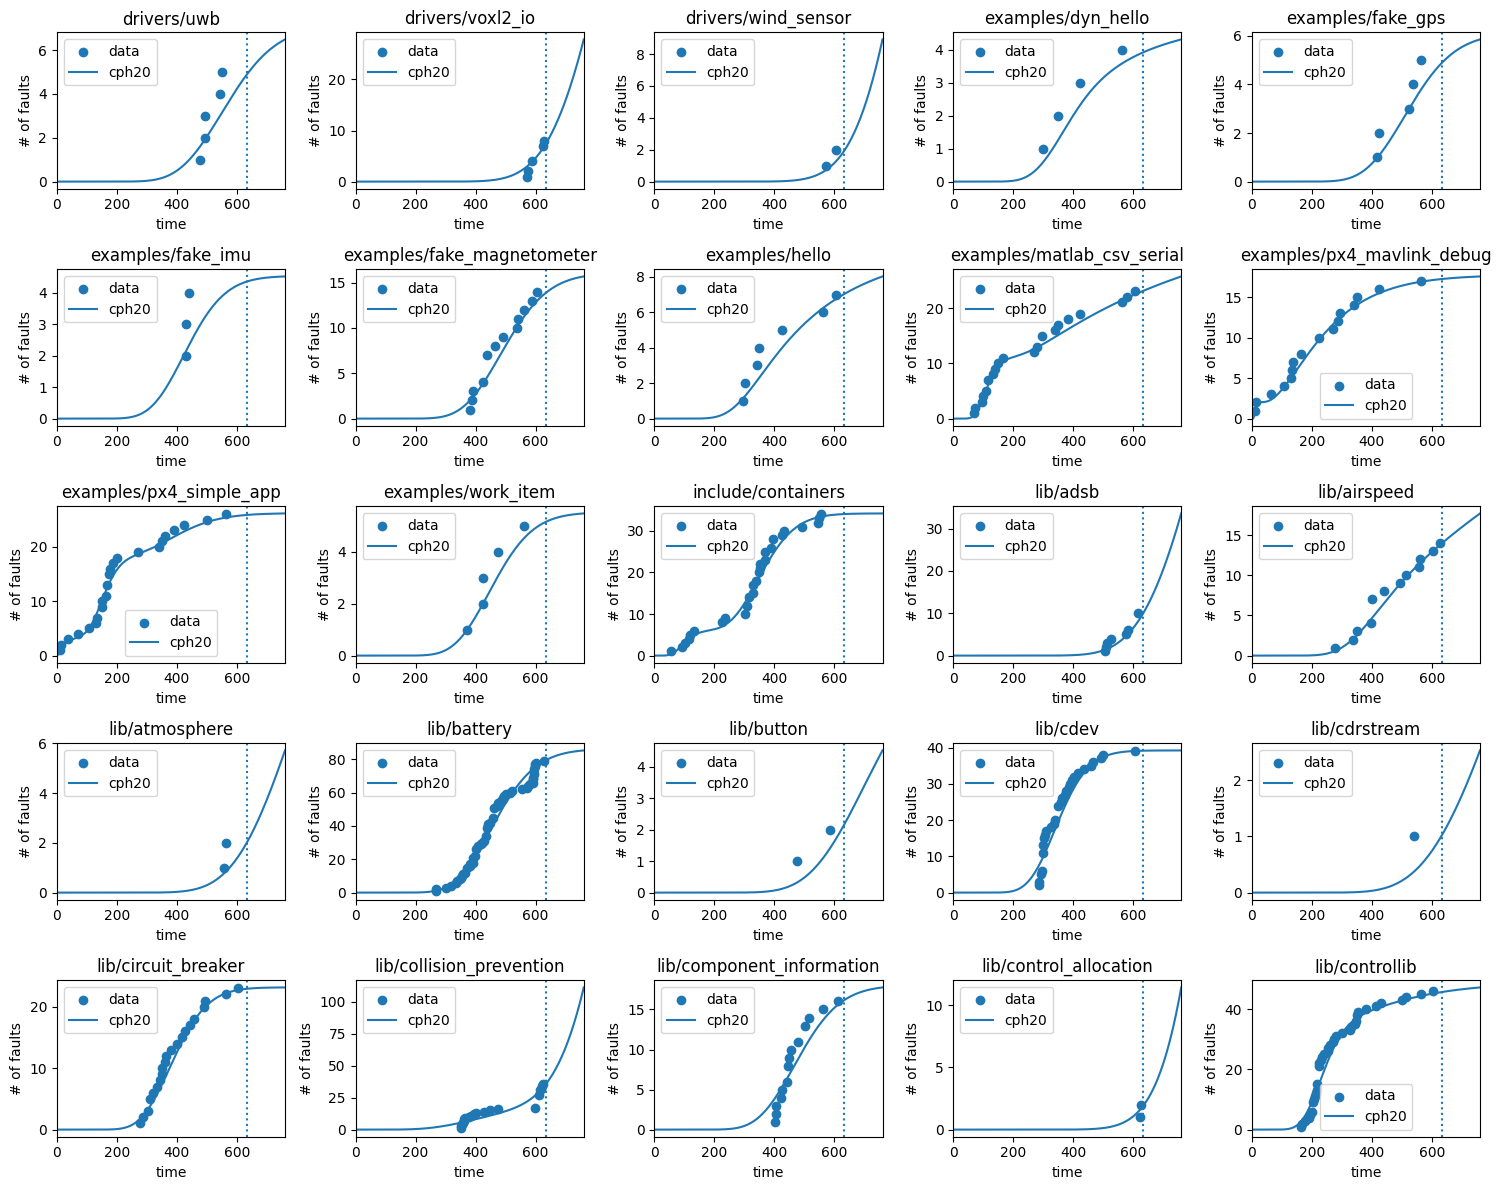

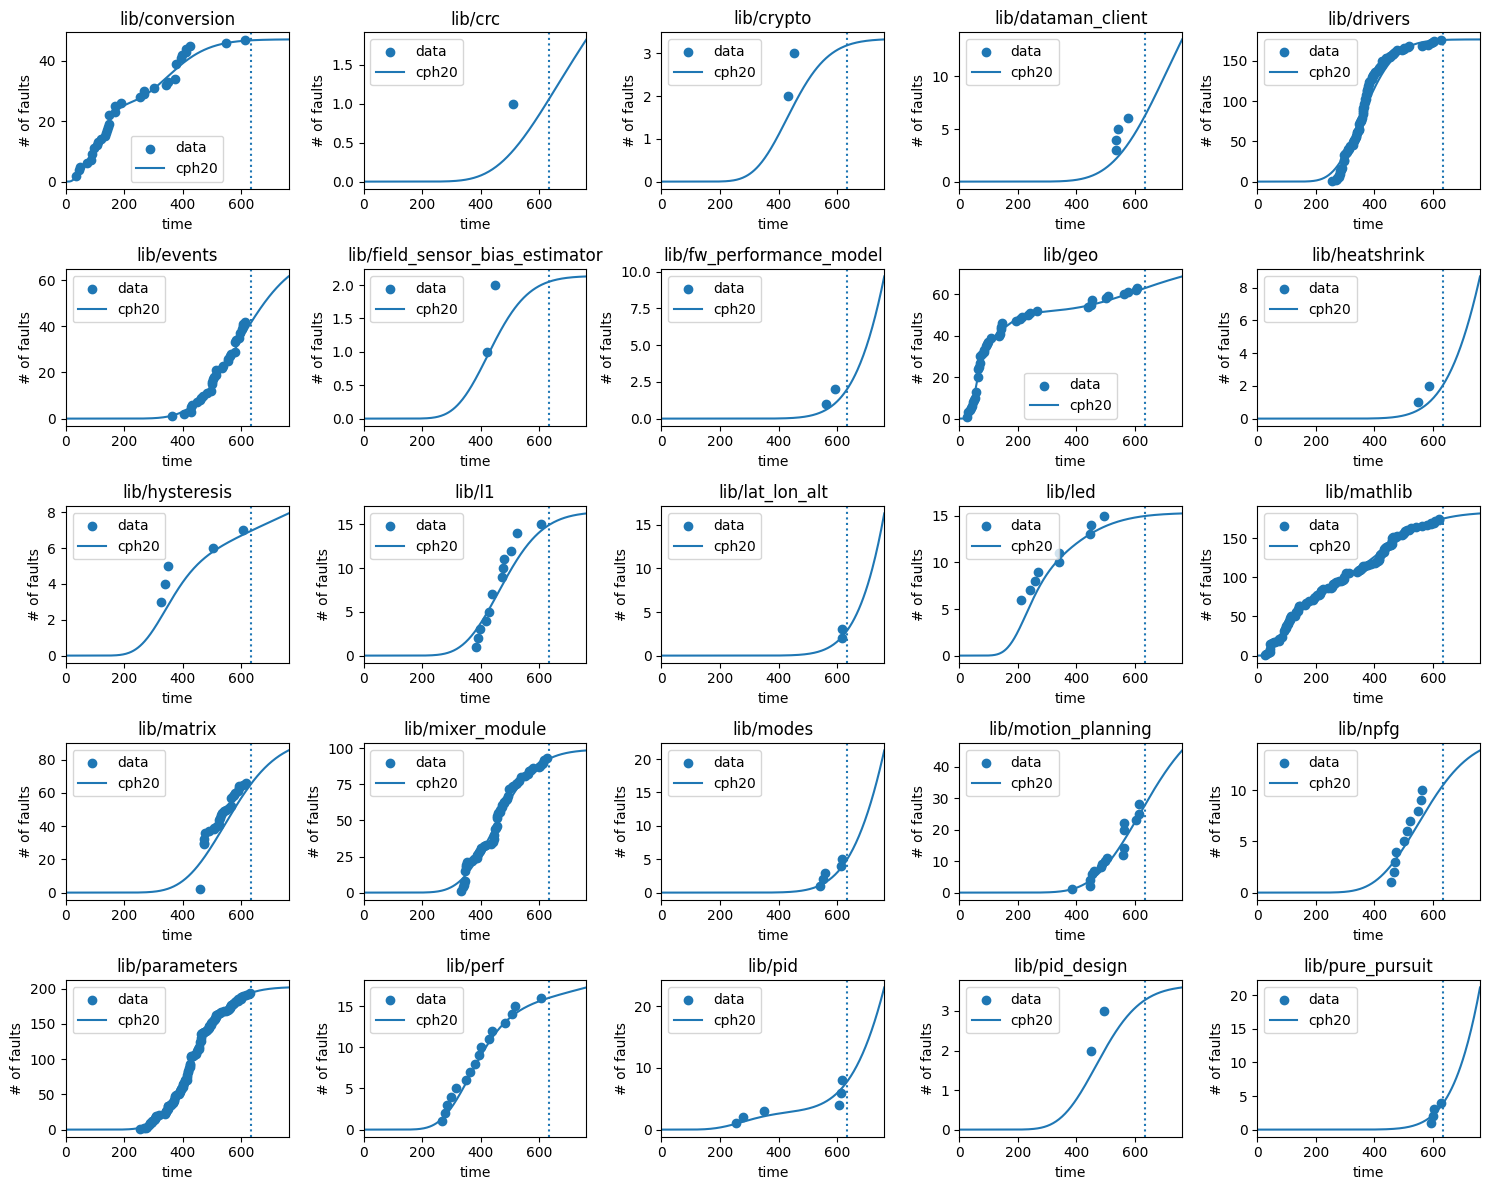

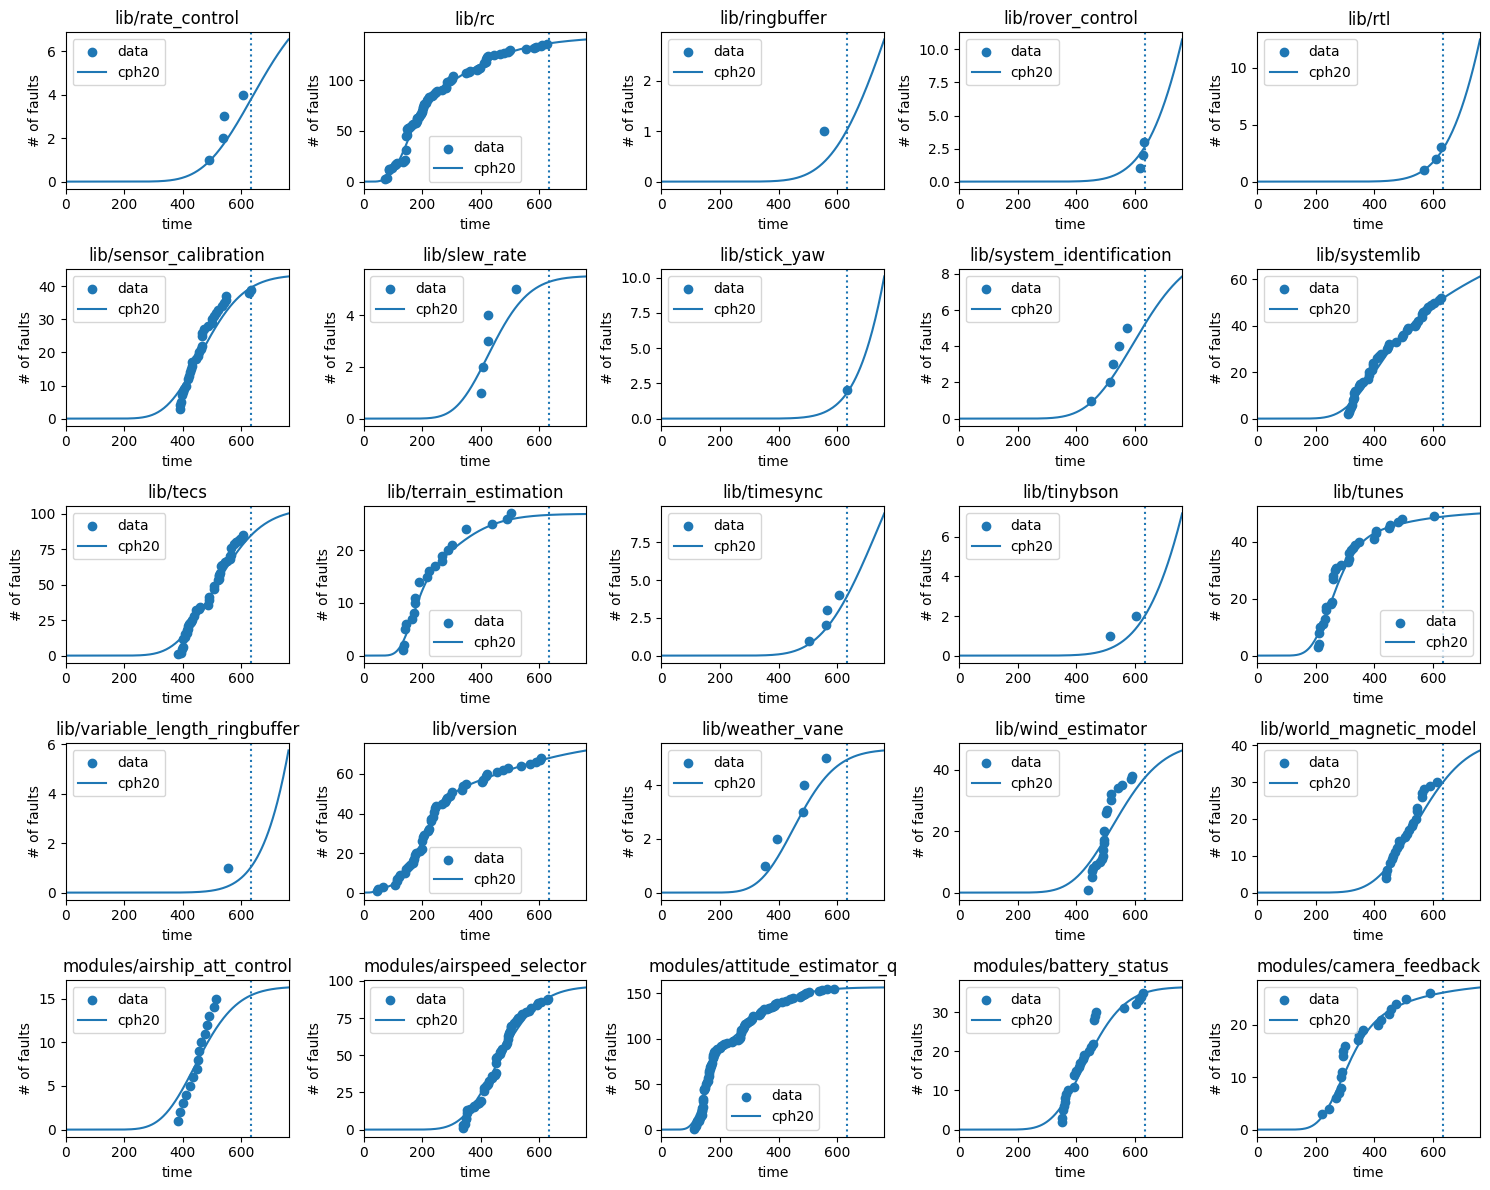

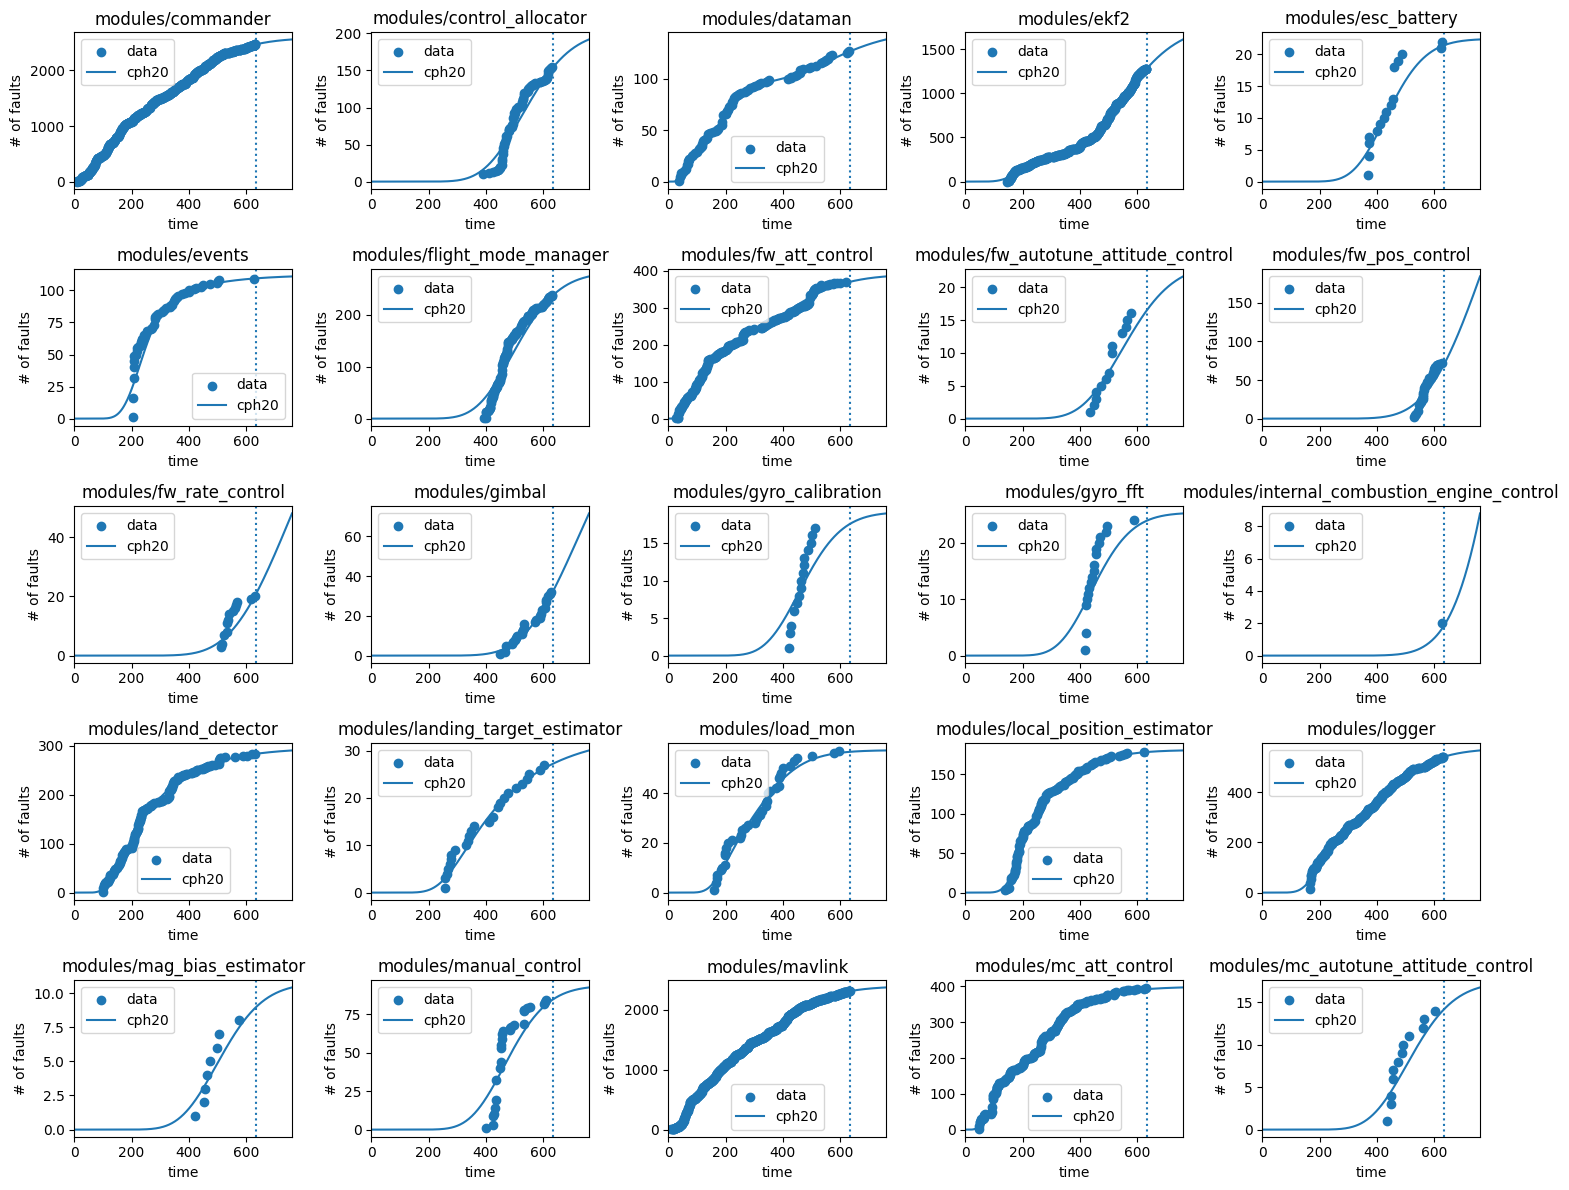

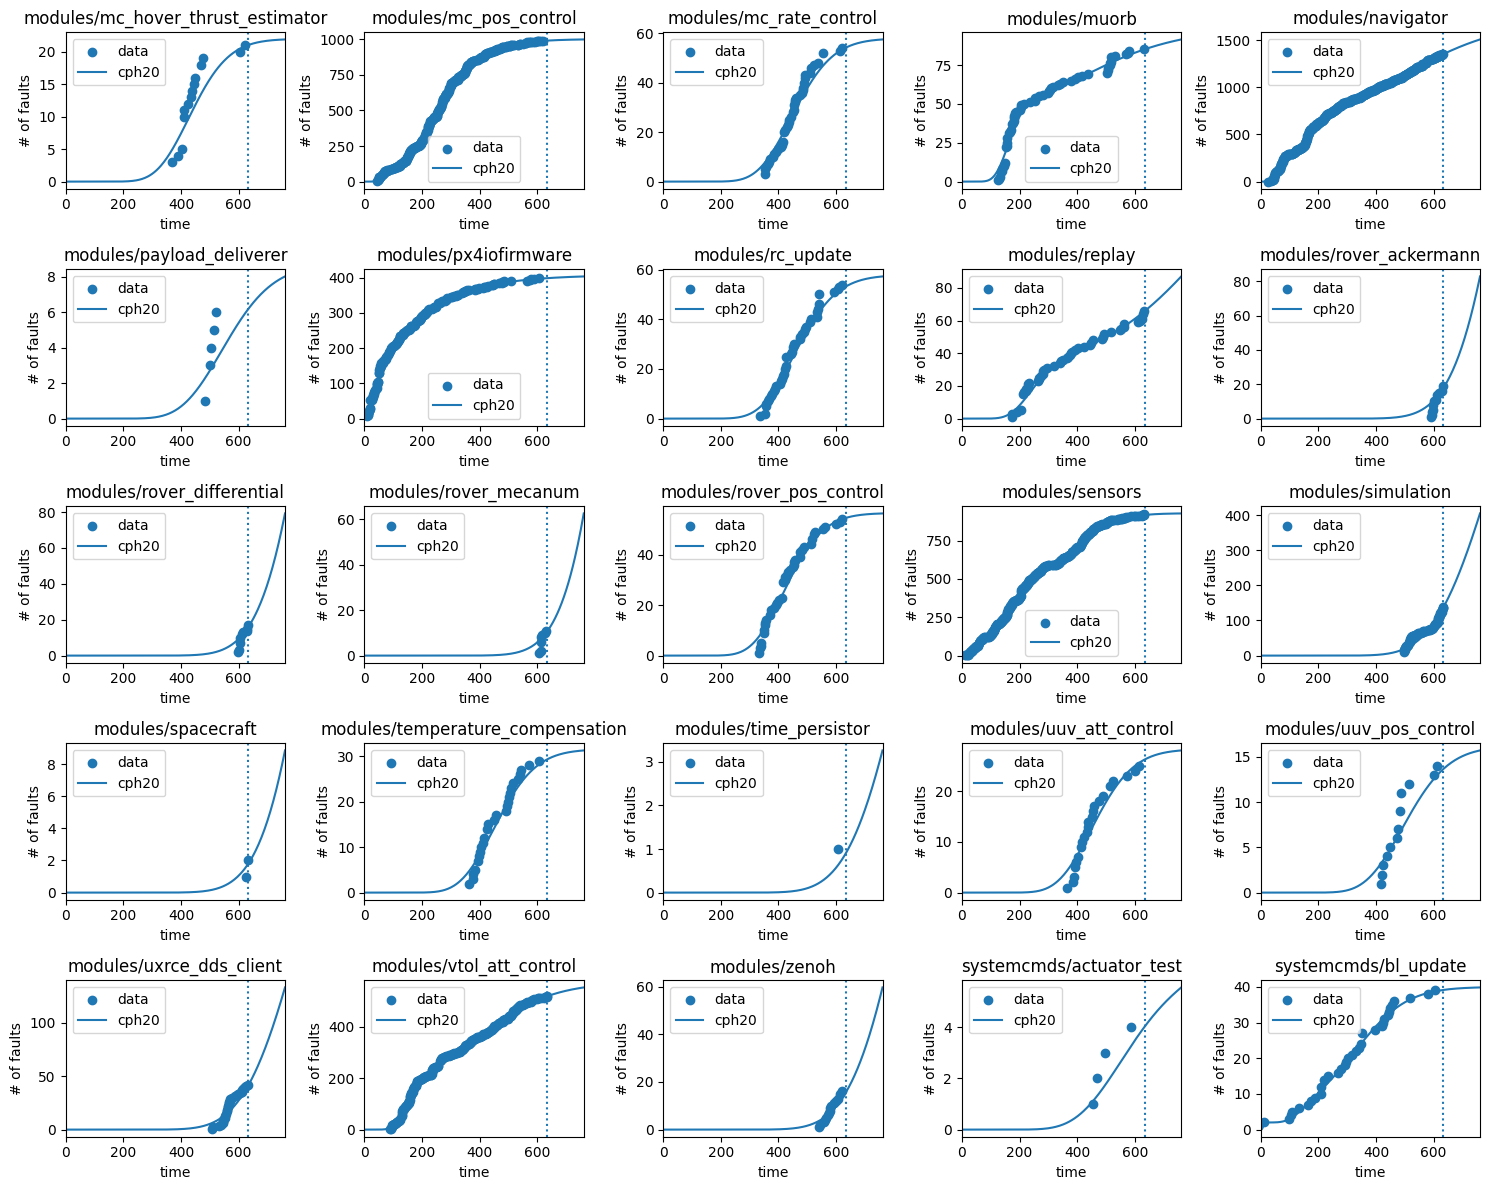

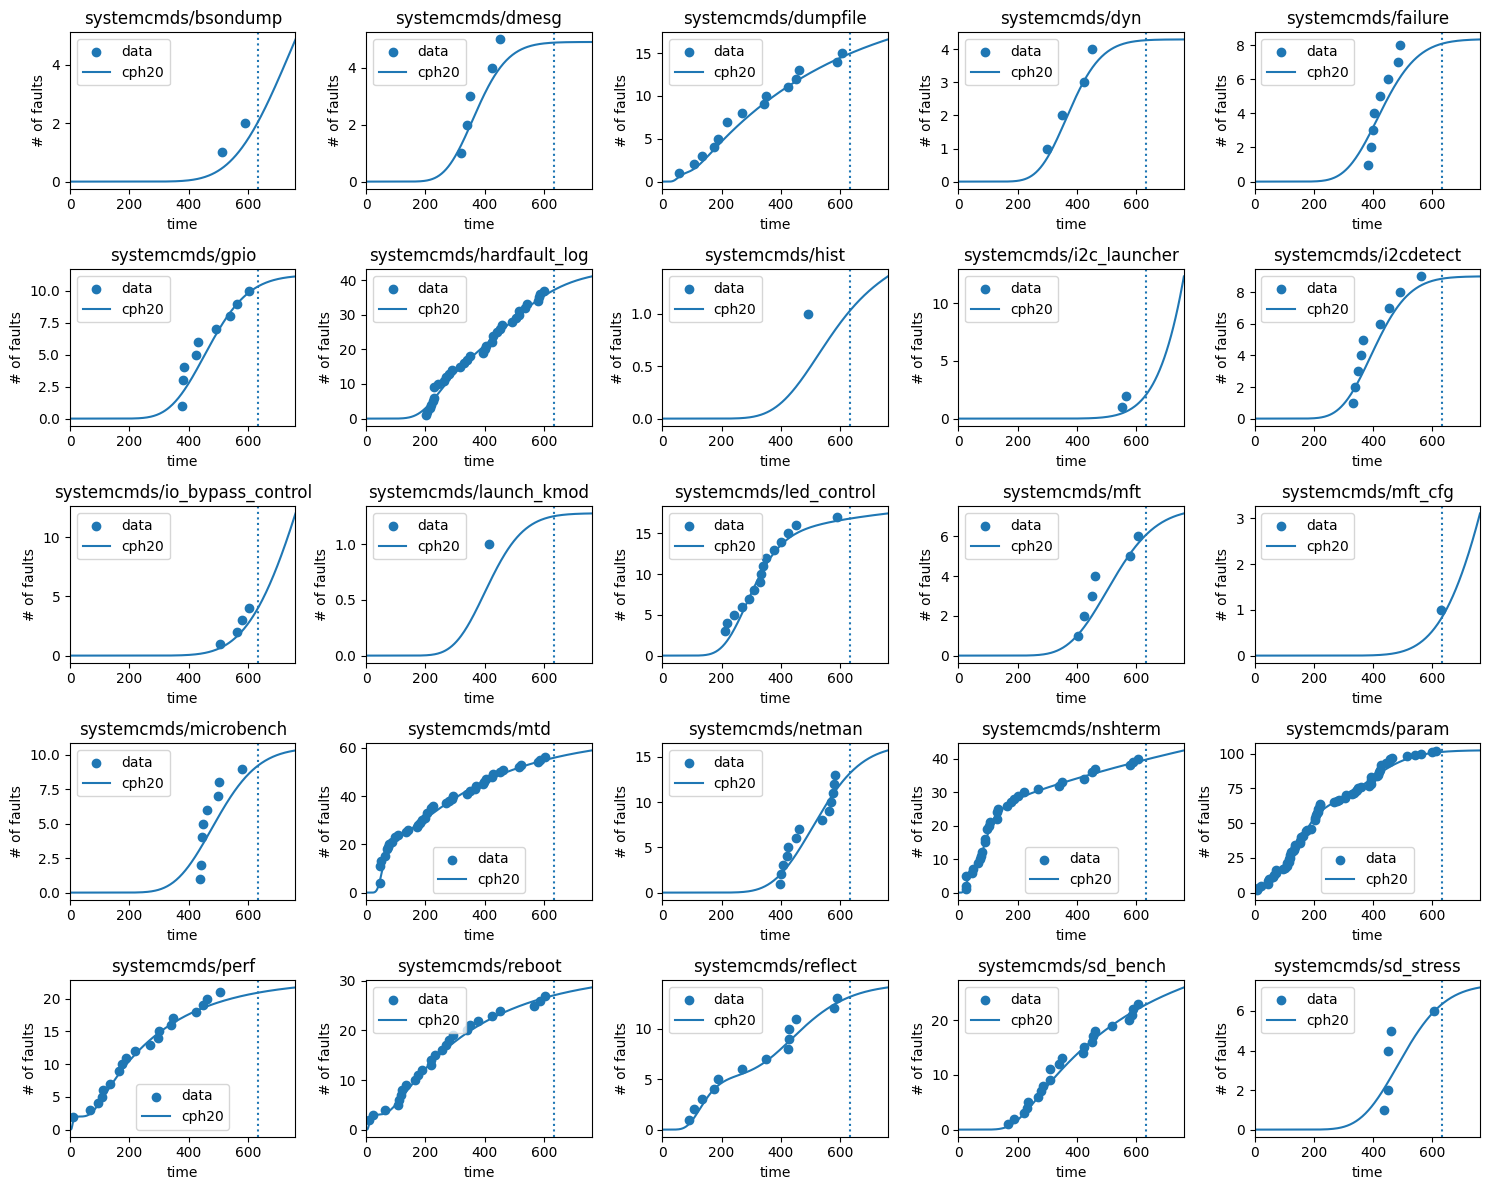

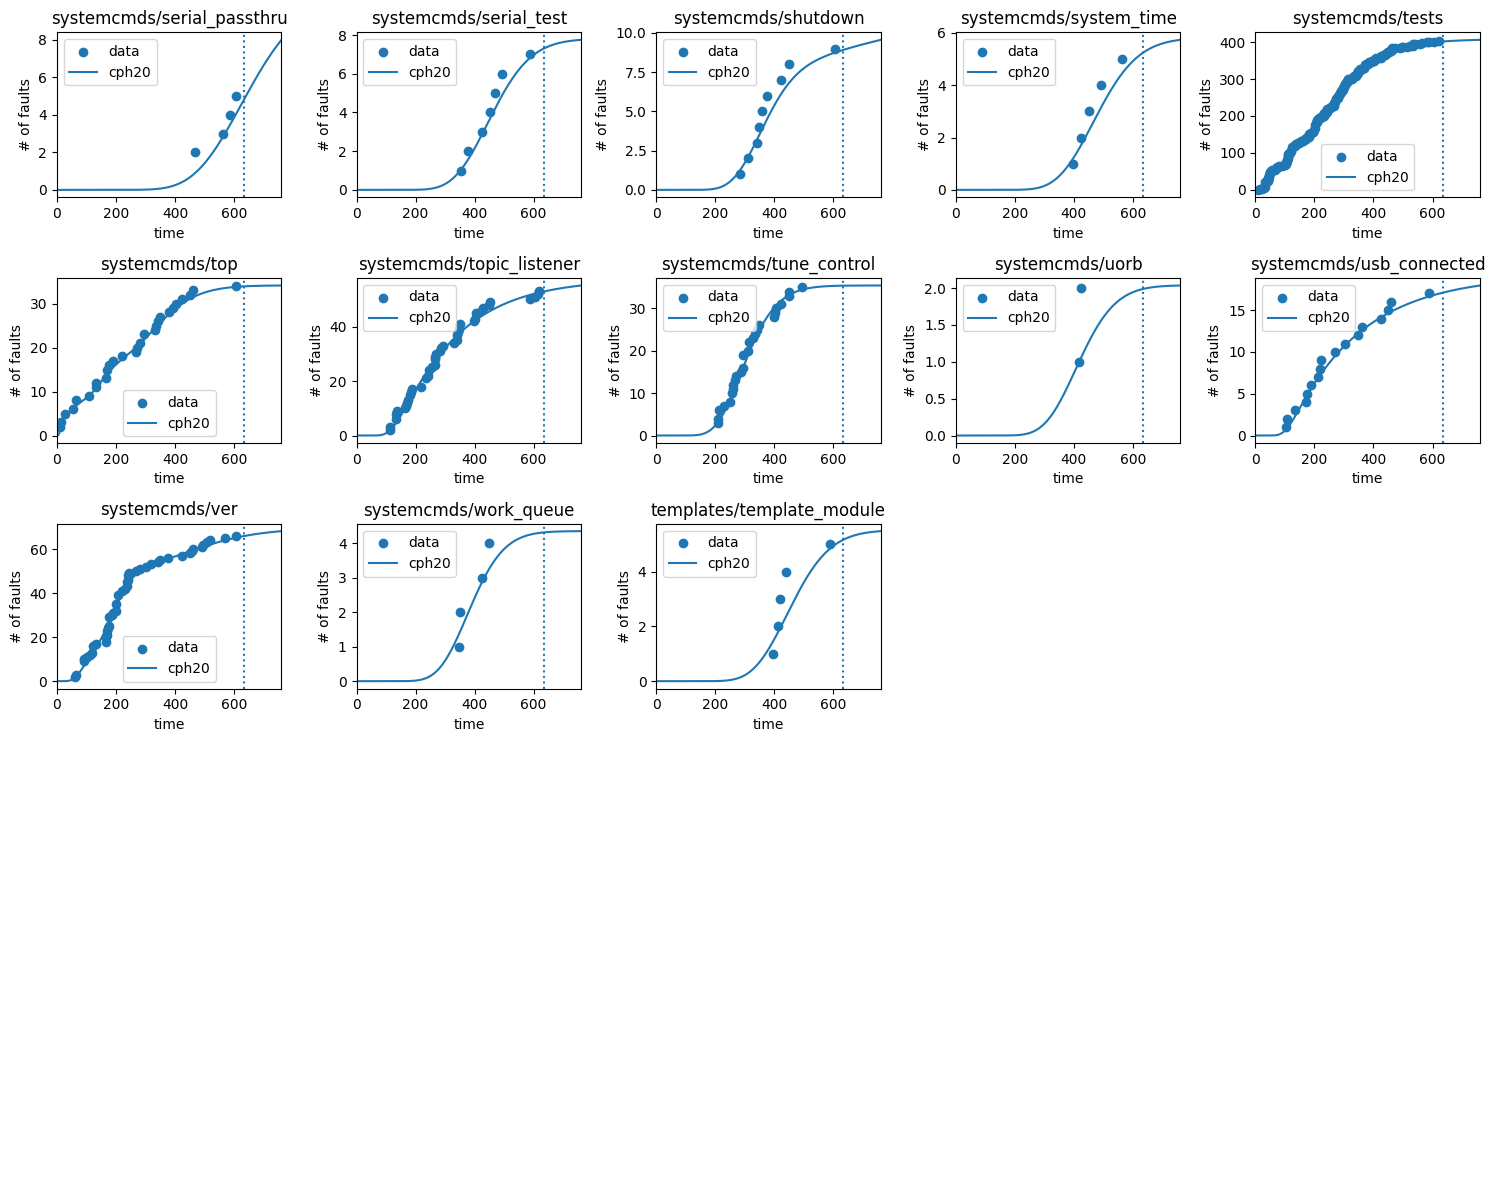

In [ ]:
# plot_models_grid(models_reg, ncols=5, nrows=5)

<Axes: title={'center': 'drivers/differential_pressure (reg)'}, xlabel='time', ylabel='# of faults'>

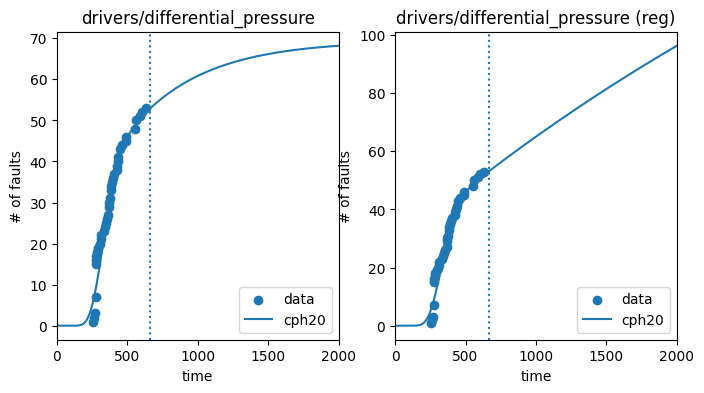

In [66]:
k = 'drivers/differential_pressure'
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
srm.plot_mvf(faultdata[k], models[k], ax=axes[0], title=k, xmax=2000)
srm.plot_mvf(faultdata[k], models_reg[k], ax=axes[1], title=k + " (reg)", xmax=2000)

In [ ]:
import joblib

In [67]:
result = joblib.load('experiment/pr_models_lambda_30.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(298.4348599801858)

In [68]:
result = joblib.load('experiment/pr_models_lambda_10.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(301.0322307295069)

In [69]:
result = joblib.load('experiment/pr_models_lambda_3.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(303.7697304051261)

In [70]:
result = joblib.load('experiment/pr_models_lambda_1.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(305.58556758293344)

In [71]:
result = joblib.load('experiment/pr_models_lambda_0.3.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(306.1460232514316)

In [72]:
result = joblib.load('experiment/pr_models_lambda_0.1.pkl')
pred_err(result['models'], faultdata0, faultdata1)

np.float64(306.8084466429999)

In [83]:
metdat = pd.read_csv('module_metrics.csv', index_col=0)

In [ ]:
in(metdat.index, df.index)

NameError: name 'intersect' is not defined

In [92]:
diff = metdat.index.symmetric_difference(df.index)

In [94]:
df = df.drop(diff, errors="ignore")

In [95]:
len(df.index)

219

In [96]:
len(metdat.index)

219